# 第 11 章 · epsilon-greedy 代码实验

[章节网页](../ch11.html)

## 运行内容

- 模拟多臂老虎机
- 比较不同 epsilon
- 绘制累计奖励

## 0. 环境与数据

In [1]:
# 导入实验库，并设置图表中文显示。
import importlib.util
import logging
import math
import subprocess
import sys
import warnings
from collections import Counter, defaultdict
from pathlib import Path

required_packages = {
    "numpy": "numpy>=1.24",
    "pandas": "pandas>=2.0",
    "matplotlib": "matplotlib>=3.7",
    "scipy": "scipy>=1.10",
    "sklearn": "scikit-learn>=1.3",
}
missing = [package for module, package in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from IPython.display import display
from scipy.optimize import dual_annealing
from scipy.signal import correlate2d
from sklearn.datasets import load_digits
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import log_loss, mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, normalize

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Bold.ttc",
    "/System/Library/Fonts/Supplemental/Arial Unicode.ttf",
    "/Library/Fonts/Arial Unicode.ttf",
    "/System/Library/Fonts/STHeiti Medium.ttc",
    "/System/Library/Fonts/STHeiti Light.ttc",
]
font_name = "DejaVu Sans"
for path in font_paths:
    if Path(path).exists():
        fm.fontManager.addfont(path)
        font_name = fm.FontProperties(fname=path).get_name()
        break

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.unicode_minus": False,
    "font.family": "sans-serif",
    "font.sans-serif": [font_name, "DejaVu Sans", "sans-serif"],
})

In [2]:
# epsilon-greedy：在探索和利用之间切换。
def run_bandit(epsilon, steps=120, seed=0):
    rng = np.random.default_rng(seed)
    true_means = np.array([0.20, 0.35, 0.55])
    estimates = np.zeros(3)
    counts = np.zeros(3)
    rows = []
    total_reward = 0.0

    for step in range(1, steps + 1):
        explore = rng.random() < epsilon
        action = rng.integers(3) if explore else int(np.argmax(estimates))
        reward = rng.normal(true_means[action], 0.08)
        counts[action] += 1
        estimates[action] += (reward - estimates[action]) / counts[action]
        total_reward += reward
        if step % 20 == 0:
            rows.append({
                "epsilon": epsilon,
                "步数": step,
                "累计奖励": round(total_reward, 2),
                "动作0次数": int(counts[0]),
                "动作1次数": int(counts[1]),
                "动作2次数": int(counts[2]),
            })
    return pd.DataFrame(rows)


bandit_trace = pd.concat([run_bandit(0.05, seed=1), run_bandit(0.25, seed=1)], ignore_index=True)
display(bandit_trace)

,epsilon,步数,累计奖励,动作0次数,动作1次数,动作2次数
0,0.05,20,4.00,20,0,0
1,0.05,40,11.09,30,0,10
2,0.05,60,22.06,30,0,30
3,0.05,80,32.61,30,0,50
4,0.05,100,42.99,31,1,68
5,0.05,120,53.40,32,1,87
6,0.25,20,10.00,1,2,17
7,0.25,40,19.61,2,5,33
8,0.25,60,30.64,2,5,53
9,0.25,80,40.89,5,5,70


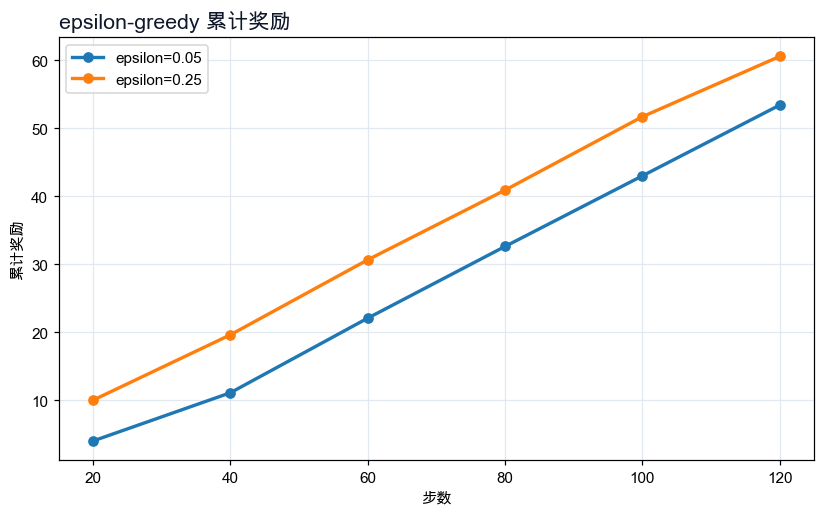

In [3]:
# 绘制不同 epsilon 的累计奖励。
fig, ax = plt.subplots(figsize=(7.6, 4.8))
for epsilon, part in bandit_trace.groupby("epsilon"):
    ax.plot(part["步数"], part["累计奖励"], marker="o", linewidth=2.2, label=f"epsilon={epsilon}")
ax.set_title("epsilon-greedy 累计奖励", loc="left", fontsize=14, fontweight="bold", color="#0f172a")
ax.set_xlabel("步数")
ax.set_ylabel("累计奖励")
ax.grid(True, color="#e2e8f0", linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()